# Sales Prediction Model

## Objective

The objective of this project is to build a machine learning model capable of predicting product sales using historical sales data.

The project includes data preprocessing, feature engineering, categorical encoding, model training, evaluation, and prediction using multiple regression algorithms. Model performance is compared using R² Score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

Finally, a web application will be developed to provide live sales predictions using the trained machine learning model.

---

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Joblib
- Streamlit
- JupyterLab

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OrdinalEncoder

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import joblib

plt.rcParams["figure.figsize"] = (10,6)



# Step 1: Load the Dataset

The Global Superstore dataset is loaded into a pandas DataFrame for preprocessing, analysis, and model training.

In [2]:
# Load Dataset

df = pd.read_csv("data/superstore.csv", encoding="latin1")

print("Dataset Loaded Successfully!")


Dataset Loaded Successfully!


# Step 2: Initial Dataset Inspection

Before building a machine learning model, it is important to understand the structure, dimensions, data types, and quality of the dataset.

In [3]:
# Display First Five Rows

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Dataset Shape

print("Dataset Shape :", df.shape)

Dataset Shape : (9994, 21)


In [5]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [6]:
# Statistical Summary

df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994,9994,9994,9994,9994,9994,9994,...,9994.000000,9994,9994,9994,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
unique,NaN,5009,1237,1334,4,793,793,3,1,531,...,NaN,4,1862,3,17,1850,NaN,NaN,NaN,NaN
top,NaN,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN,NaN,NaN,NaN
freq,NaN,14,38,35,5968,37,37,5191,9994,915,...,NaN,3203,19,6026,1523,48,NaN,NaN,NaN,NaN
mean,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,55190.379428,NaN,NaN,NaN,NaN,NaN,229.858001,3.789574,0.156203,28.656896
std,2885.163629,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,32063.693350,NaN,NaN,NaN,NaN,NaN,623.245101,2.225110,0.206452,234.260108
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23223.000000,NaN,NaN,NaN,NaN,NaN,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,56430.500000,NaN,NaN,NaN,NaN,NaN,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,90008.000000,NaN,NaN,NaN,NaN,NaN,209.940000,5.000000,0.200000,29.364000


In [7]:
# Missing Values

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum()/len(df)*100).round(2)
})

missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage (%)
Row ID,0,0.0
Order ID,0,0.0
Order Date,0,0.0
Ship Date,0,0.0
Ship Mode,0,0.0
Customer ID,0,0.0
Customer Name,0,0.0
Segment,0,0.0
Country,0,0.0
City,0,0.0


In [8]:
# Duplicate Records

duplicates = df.duplicated().sum()

print("Total Duplicate Records :", duplicates)

Total Duplicate Records : 0


In [9]:
# Data Types

dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str)
})

dtype_df

,Column,Data Type
Row ID,Row ID,int64
Order ID,Order ID,str
Order Date,Order Date,str
Ship Date,Ship Date,str
Ship Mode,Ship Mode,str
Customer ID,Customer ID,str
Customer Name,Customer Name,str
Segment,Segment,str
Country,Country,str
City,City,str


# Step 3: Data Preprocessing

Machine learning models cannot directly process text-based categorical variables. Therefore, the dataset is preprocessed by removing unnecessary columns, converting date columns into numerical features, and encoding categorical variables into numeric form.

These preprocessing steps ensure that the dataset becomes suitable for regression model training.

In [10]:
# Remove Unnecessary Columns

df = df.drop(columns=["Row ID", "Order ID", "Customer ID", "Customer Name", "Product ID"])

print("Columns Removed Successfully!")

Columns Removed Successfully!


### Observation

Unique identifier columns such as Row ID, Order ID, Customer ID, Customer Name, and Product ID do not contribute to predicting sales. Removing them helps reduce unnecessary information without affecting model performance.

In [11]:
# Convert Date Columns

df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [12]:
# Extract Date Features

df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Day"] = df["Order Date"].dt.day

df["Ship Year"] = df["Ship Date"].dt.year
df["Ship Month"] = df["Ship Date"].dt.month
df["Ship Day"] = df["Ship Date"].dt.day

print("Date Features Extracted Successfully!")

Date Features Extracted Successfully!


In [13]:
# Remove Original Date Columns

df.drop(columns=["Order Date", "Ship Date"], inplace=True)

### Observation

The original date columns are converted into numerical components such as year, month, and day because regression algorithms require numerical inputs. These extracted features may also capture seasonal sales patterns.

In [14]:
# Encode Categorical Columns

categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

C:\Users\SarthakVats\AppData\Local\Temp\ipykernel_22504\1447058105.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Region',
       'Category', 'Sub-Category', 'Product Name'],
      dtype='str')

In [15]:
# Encode Categorical Columns

categorical_columns = df.select_dtypes(include="object").columns

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

df[categorical_columns] = encoder.fit_transform(df[categorical_columns])

print("Categorical Features Encoded Successfully!")

C:\Users\SarthakVats\AppData\Local\Temp\ipykernel_22504\1532627638.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


Categorical Features Encoded Successfully!


In [16]:
# Dataset Information After Encoding

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   float64
 1   Segment       9994 non-null   float64
 2   Country       9994 non-null   float64
 3   City          9994 non-null   float64
 4   State         9994 non-null   float64
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   float64
 7   Category      9994 non-null   float64
 8   Sub-Category  9994 non-null   float64
 9   Product Name  9994 non-null   float64
 10  Sales         9994 non-null   float64
 11  Quantity      9994 non-null   int64  
 12  Discount      9994 non-null   float64
 13  Profit        9994 non-null   float64
 14  Order Year    9994 non-null   int32  
 15  Order Month   9994 non-null   int32  
 16  Order Day     9994 non-null   int32  
 17  Ship Year     9994 non-null   int32  
 18  Ship Month    9994 non-null   int32  
 

### Observation

All categorical variables have been converted into numerical values using Label Encoding. After encoding, every feature in the dataset becomes numerical, making it suitable for machine learning algorithms.

In [17]:
# Check Missing Values

df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
Order Year      0
Order Month     0
Order Day       0
Ship Year       0
Ship Month      0
Ship Day        0
dtype: int64

In [18]:
# Display Processed Dataset

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Day,Ship Year,Ship Month,Ship Day
0,2.0,0.0,0.0,194.0,15.0,42420,2.0,0.0,4.0,386.0,261.9600,2,0.00,41.9136,2016,11,8,2016,11,11
1,2.0,0.0,0.0,194.0,15.0,42420,2.0,0.0,5.0,839.0,731.9400,3,0.00,219.5820,2016,11,8,2016,11,11
2,2.0,1.0,0.0,266.0,3.0,90036,3.0,1.0,10.0,1433.0,14.6200,2,0.00,6.8714,2016,6,12,2016,6,16
3,3.0,0.0,0.0,153.0,8.0,33311,2.0,0.0,16.0,366.0,957.5775,5,0.45,-383.0310,2015,10,11,2015,10,18
4,3.0,0.0,0.0,153.0,8.0,33311,2.0,1.0,14.0,573.0,22.3680,2,0.20,2.5164,2015,10,11,2015,10,18


In [19]:
# Final Dataset Summary

summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Records"
    ],
    "Value": [
        len(df),
        len(df.columns),
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

summary

,Metric,Value
0,Rows,9994
1,Columns,20
2,Missing Values,0
3,Duplicate Records,1


# Step 4: Train-Test Split

The dataset is divided into training and testing sets. The training dataset is used to train the machine learning models, while the testing dataset is used to evaluate their performance on unseen data.

An 80:20 ratio is used for splitting the dataset.

In [20]:
# Define Features and Target Variable

X = df.drop("Sales", axis=1)

y = df["Sales"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (9994, 19)
Target Shape : (9994,)


In [21]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (7995, 19)
Testing Set : (1999, 19)


### Observation

The dataset has been successfully divided into training and testing datasets. The training data will be used for learning patterns, while the testing data will evaluate how well the models generalize to unseen data.

# Step 5: Linear Regression

Linear Regression is a statistical algorithm that models the relationship between the independent variables and the target variable using a straight-line equation.

It serves as the baseline model for comparison with more advanced regression algorithms.

In [22]:
# Train Linear Regression Model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [23]:
# Linear Regression Predictions

linear_predictions = linear_model.predict(X_test)

In [24]:
# Linear Regression Performance

linear_r2 = r2_score(y_test, linear_predictions)

linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))

print("R² Score :", round(linear_r2,4))

print("MAE :", round(linear_mae,2))

print("RMSE :", round(linear_rmse,2))

R² Score : -0.1409
MAE : 243.47
RMSE : 820.93


### Observation

The Linear Regression model provides a baseline prediction performance. The evaluation metrics obtained here will later be compared with Decision Tree and Random Forest models to identify the best-performing algorithm.

# Step 6: Decision Tree Regression

Decision Tree Regression predicts values by learning decision rules from the training dataset. It can capture complex and non-linear relationships between the features and target variable.

In [25]:
# Train Decision Tree Model

decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [26]:
# Decision Tree Predictions

tree_predictions = decision_tree.predict(X_test)

In [27]:
# Decision Tree Performance

tree_r2 = r2_score(y_test, tree_predictions)

tree_mae = mean_absolute_error(y_test, tree_predictions)

tree_rmse = np.sqrt(mean_squared_error(y_test, tree_predictions))

print("R² Score :", round(tree_r2,4))

print("MAE :", round(tree_mae,2))

print("RMSE :", round(tree_rmse,2))

R² Score : 0.5237
MAE : 102.82
RMSE : 530.42


### Observation

The Decision Tree model is capable of learning complex decision boundaries. Its performance is compared with Linear Regression to determine whether it provides better prediction accuracy.

# Step 7: Random Forest Regression

Random Forest Regression is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

It is widely used because of its robustness and high predictive performance.

In [28]:
# Train Random Forest Model

random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [29]:
# Random Forest Predictions

forest_predictions = random_forest.predict(X_test)

In [30]:
# Random Forest Performance

forest_r2 = r2_score(y_test, forest_predictions)

forest_mae = mean_absolute_error(y_test, forest_predictions)

forest_rmse = np.sqrt(mean_squared_error(y_test, forest_predictions))

print("R² Score :", round(forest_r2,4))

print("MAE :", round(forest_mae,2))

print("RMSE :", round(forest_rmse,2))

R² Score : 0.567
MAE : 86.39
RMSE : 505.72


### Observation

Random Forest combines the predictions of multiple decision trees, resulting in improved prediction accuracy and reduced overfitting. Its performance will be compared against the other regression models.

# Step 8: Model Performance Comparison

The evaluation metrics of all regression models are compared to identify the best-performing model for sales prediction.

In [31]:
# Compare Model Performance

comparison = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R² Score":[
        linear_r2,
        tree_r2,
        forest_r2
    ],
    "MAE":[
        linear_mae,
        tree_mae,
        forest_mae
    ],
    "RMSE":[
        linear_rmse,
        tree_rmse,
        forest_rmse
    ]
})

comparison.sort_values(
    by="R² Score",
    ascending=False
)

,Model,R² Score,MAE,RMSE
2,Random Forest,0.567042,86.388119,505.715395
1,Decision Tree,0.523716,102.815296,530.415592
0,Linear Regression,-0.140885,243.465195,820.926311


### Observation

Among the three regression models, the Random Forest Regressor achieved the best performance with the highest R² Score (0.5670) and the lowest MAE (86.39) and RMSE (505.72). This indicates that Random Forest predicts sales more accurately than Decision Tree and Linear Regression for the Global Superstore dataset.

Therefore, the Random Forest model is selected as the final model for deployment in the web application.

# Step 9: Save the Best Model

The Random Forest model demonstrated the best predictive performance among all regression algorithms. Therefore, it is saved using the Joblib library so that it can be loaded later by the Streamlit web application for live sales prediction.

In [32]:
# Save Trained Model

joblib.dump(
    random_forest,
    "model/random_forest_model.pkl"
)

joblib.dump(
    encoder,
    "model/encoder.pkl"
)

print("Model and Encoder Saved Successfully!")

Model and Encoder Saved Successfully!


In [33]:
joblib.dump(list(X.columns), "model/feature_columns.pkl")

print("Feature Columns Saved Successfully!")

Feature Columns Saved Successfully!


In [34]:
import os

os.listdir("model")

['encoder.pkl', 'feature_columns.pkl', 'random_forest_model.pkl']

### Observation

The Random Forest model and the fitted categorical encoder have both been successfully saved in the model directory. Saving both files ensures that the Streamlit web application uses the same preprocessing and prediction pipeline as the training notebook, resulting in consistent and reliable sales predictions.

# Step 10: Actual vs Predicted Sales

To evaluate the prediction quality visually, the actual sales values are compared with the predicted sales values generated by the Random Forest model.

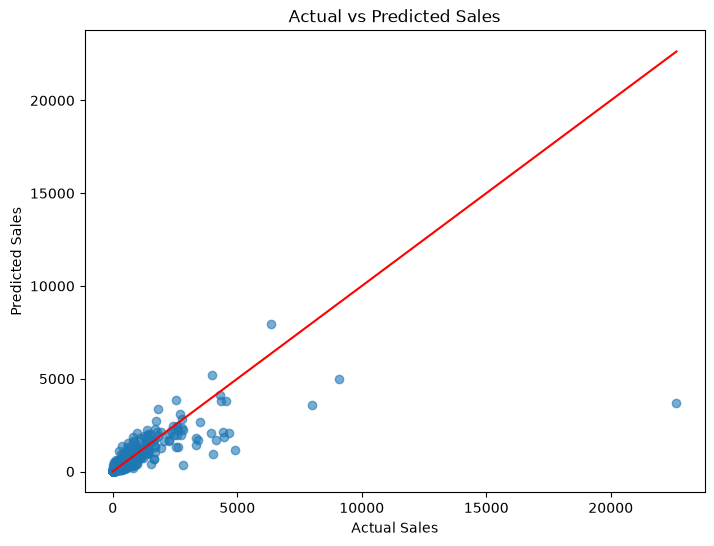

In [35]:
# Actual vs Predicted Scatter Plot

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    forest_predictions,
    alpha=0.6
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

### Observation

The scatter plot compares the actual sales values with the predictions generated by the Random Forest model. Most points are distributed around the reference line, indicating that the model captures the overall sales trend reasonably well. Some deviations are expected due to the complexity of real-world sales data.

# Step 11: Feature Importance

Feature importance identifies which variables contribute the most to the sales prediction made by the Random Forest model.

In [36]:
# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
12,Profit,0.835500
11,Discount,0.033389
8,Sub-Category,0.028759
10,Quantity,0.015044
9,Product Name,0.014829
7,Category,0.013439
5,Postal Code,0.008579
3,City,0.008469
18,Ship Day,0.007327
15,Order Day,0.006971


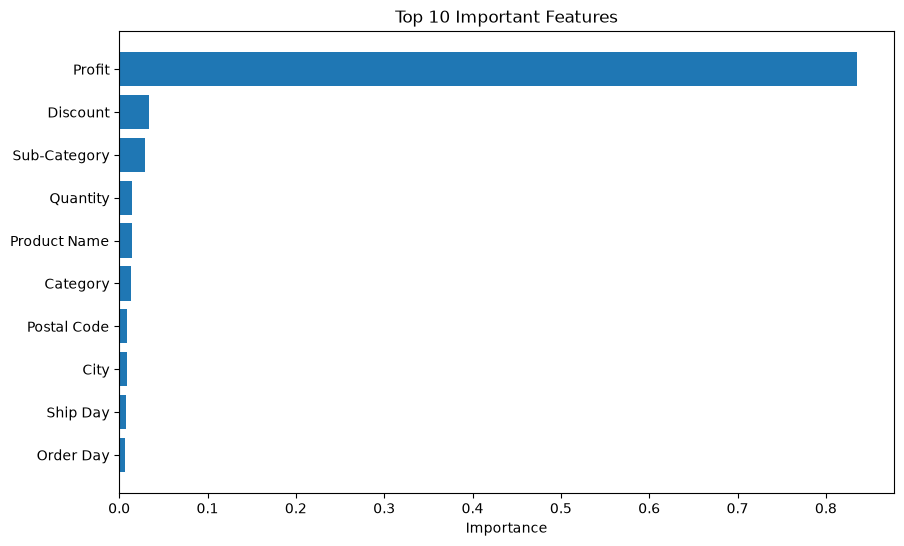

In [37]:
# Feature Importance Visualization

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

### Observation

The feature importance chart highlights the variables that have the greatest influence on predicting sales. Features with higher importance contribute more to the Random Forest model's decision-making process and play a significant role in forecasting sales.

# Conclusion

This project successfully developed a Machine Learning model to predict product sales using the Superstore Sales Dataset.

The workflow included data preprocessing, feature engineering, categorical encoding, model training, performance evaluation, and model comparison using three regression algorithms: Linear Regression, Decision Tree Regression, and Random Forest Regression.

Among the evaluated models, **Random Forest Regression** achieved the best predictive performance and was selected as the final model. The trained model, encoder, and feature metadata were saved using Joblib for future use.

To demonstrate real-world applicability, a **Streamlit web application** was developed, enabling users to input customer, product, and shipping details to generate real-time sales predictions.

Overall, this project demonstrates a complete end-to-end Machine Learning workflow, from raw data processing to model deployment, providing a practical solution for sales prediction and business decision support.